<a href="https://colab.research.google.com/github/corrielynnyuill-debug/Assignment14-CLY/blob/main/Assignment14_CorrieLynnYuill.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
from sklearn.datasets import fetch_openml

adult = fetch_openml(name='adult', version=2, as_frame=True)
df = adult.frame
print(df.head())

# Basic cleaning
df = df.replace('?', np.nan)
df = df.dropna()

# define target and sensitive attribute
X = df.drop('class', axis=1)
y = df['class']

sensitive_attribute = df['sex']

# Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

sens_train = sensitive_attribute.loc[X_train.index]
sens_test = sensitive_attribute.loc[X_test.index]

# Build logistic regression pipeline
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# Train the model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))










   age  workclass  fnlwgt     education  education-num      marital-status  \
0   25    Private  226802          11th              7       Never-married   
1   38    Private   89814       HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  160323  Some-college             10  Married-civ-spouse   
4   18        NaN  103497  Some-college             10       Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                NaN    Own-child  White  Female             0             0   

   hours-per-week native-country  class  
0       

Threshold 0.35: selection_rate = 0.5359
Threshold 0.3: selection_rate = 0.5981
Threshold 0.25: selection_rate = 0.6718
Threshold 0.2: selection_rate = 0.7537
Threshold 0.15: selection_rate = 0.8381
Adjusted Metrics:
 selection_rate         0.598121
Accuracy               0.604201
True Positive Rate     0.908118
False Positive Rate    0.504042
dtype: float64
Adjusted Group Metrics:
         selection_rate  Accuracy  True Positive Rate  False Positive Rate
sex                                                                      
Female        0.526045  0.566141            0.870523             0.522896
Male          0.632447  0.622327            0.915381             0.492702


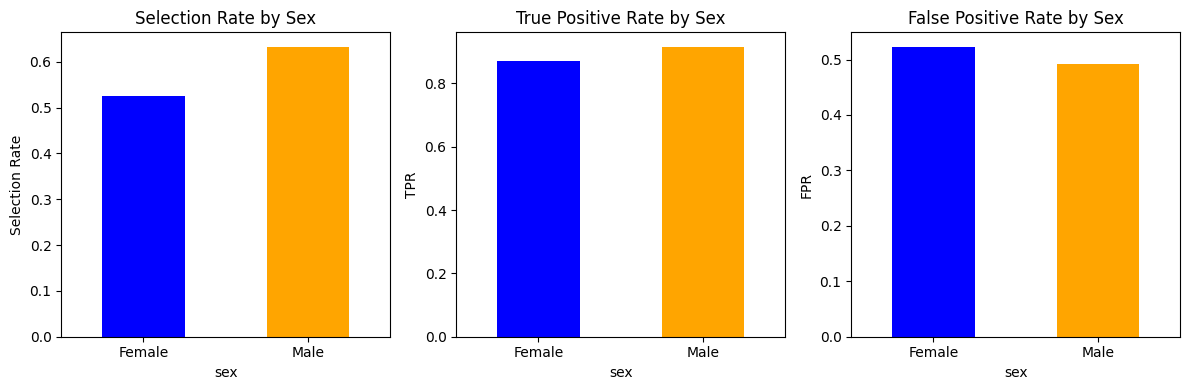

In [11]:
# Fairness Analysis
# !pip install fairlearn

from fairlearn.metrics import MetricFrame, selection_rate
from sklearn.metrics import accuracy_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

# Sensitve attribute aligned with X Test
sens_test = sensitive_attribute.loc[X_test.index]

# Convert true labels to binary
y_test_bin = (y_test == '>50K').astype(int)

# Get predicted probabilities
y_proba = model.predict_proba(X_test)[:, 1]

# Adjust threshold Params
for t in [0.35, 0.30, 0.25, 0.20, 0.15]:
    y_pred_adj = (y_proba > t).astype(int)
    sr = selection_rate(y_test, y_pred_adj)
    print(f"Threshold {t}: selection_rate = {sr:.4f}")

# Define threshold
threshold = 0.30
y_pred_adj = (y_proba > threshold).astype(int)

# Define metric functions
def true_positive_rate(y_true, y_pred):
  return recall_score(y_true, y_pred, pos_label=1)

def false_positive_rate(y_true, y_pred):
  return recall_score(y_true, y_pred, pos_label=0)

# Build MetricFrame
metrics = {
    'selection_rate': selection_rate,
    'Accuracy': accuracy_score,
    'True Positive Rate': true_positive_rate,
    'False Positive Rate': false_positive_rate
}

# Compute Metrics
mf_adj = MetricFrame(
    metrics=metrics,
    y_true=y_test_bin,
    y_pred=y_pred_adj,
    sensitive_features=sens_test
)

print('Adjusted Metrics:\n', mf_adj.overall)
print('Adjusted Group Metrics:\n', mf_adj.by_group)

# Adjusted Plots
plt.figure(figsize=(12, 4))

# Selection Rate
plt.subplot(1, 3, 1)
mf_adj.by_group["selection_rate"].plot(kind="bar", color=["Blue", "Orange"])
plt.title("Selection Rate by Sex")
plt.ylabel("Selection Rate")
plt.xticks(rotation=0)

# True Positive Rate
plt.subplot(1, 3, 2)
mf_adj.by_group["True Positive Rate"].plot(kind="bar", color=["Blue", "Orange"])
plt.title("True Positive Rate by Sex")
plt.ylabel("TPR")
plt.xticks(rotation=0)

# False Positive Rate
plt.subplot(1, 3, 3)
mf_adj.by_group["False Positive Rate"].plot(kind="bar", color=["Blue", "Orange"])
plt.title("False Positive Rate by Sex")
plt.ylabel("FPR")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


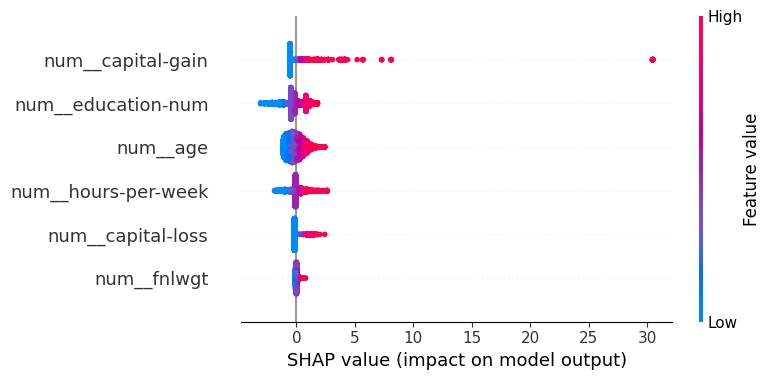

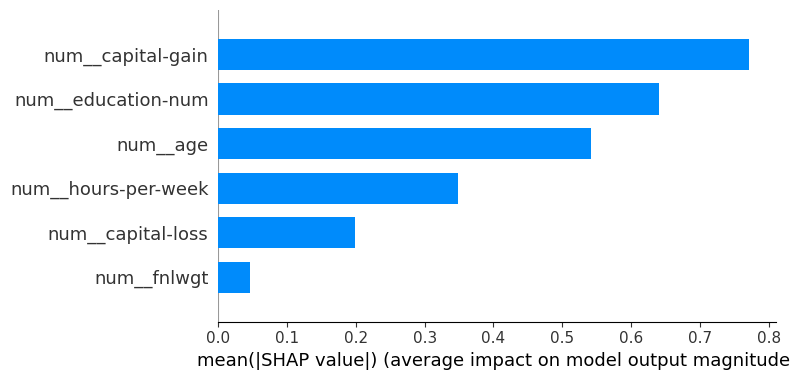

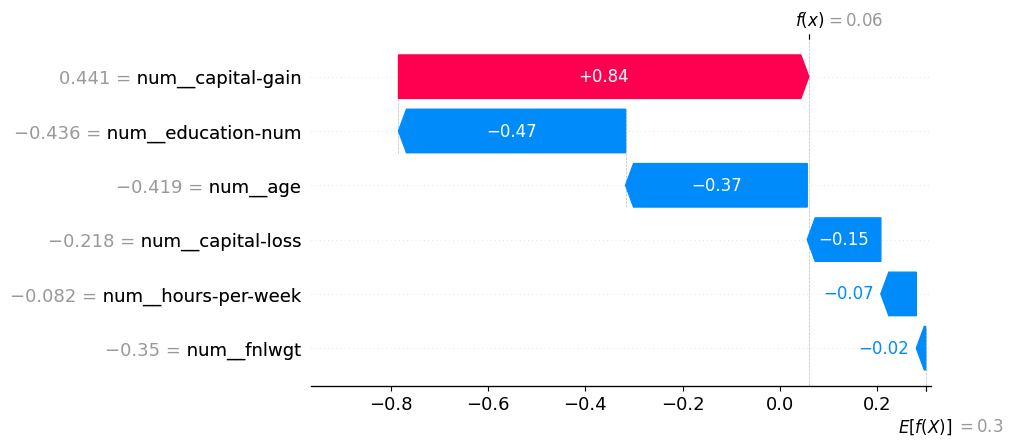

In [16]:
!pip install shap lime
import shap
from lime.lime_tabular import LimeTabularExplainer

# Extract the processed feature matrix
X_test_transformed = model.named_steps['preprocessor'].transform(X_test)

# Extract the classifier
clf = model.named_steps['classifier']

# Create SHAP explainer for linear models
explainer = shap.LinearExplainer(clf, X_test_transformed, feature_perturbation='interventional')
shap_values = explainer.shap_values(X_test_transformed)

# Get feature names from the Column Transformer
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# SHAP Summary Plot (Global Importance)
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

# SHAP Bar Plot (Global Importance)
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, plot_type='bar')

# SHAP Waterfall Plot (Local Explaination)
index = 10

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[index],
        base_values=explainer.expected_value,
        data=X_test_transformed[index],
        feature_names=feature_names
    ))

# LIME Explaination (Local)
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_test_transformed),
    feature_names=feature_names,
    mode='classification'
)

# Explain a single prediction with LIME
exp = lime_explainer.explain_instance(
    data_row=X_test_transformed[index],
    predict_fn=clf.predict_proba
)

exp.show_in_notebook(show_table=True)
